In [22]:
import sys  
sys.path.insert(1, '../src')

from pathlib import Path
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from skimage.morphology import local_maxima

from tps_parser import parse_tps_file
from UNet_class_and_functions import *

from tqdm.auto import tqdm
tqdm.pandas()

In [2]:
PROJECT_ROOT = Path.cwd().parent

LOGS_PATH = PROJECT_ROOT / 'logs' / 'wing_extraction_log.csv'
CROP_ROOT = PROJECT_ROOT / 'data' / 'images' / 'wing_crops'
PREDICT_ROOT = PROJECT_ROOT / 'out' / 'predict'
MODEL_DIR = PROJECT_ROOT / 'data' / 'models' / 'best_model'

METADATAS_OUT = PROJECT_ROOT / 'data' / 'annotations' / 'metadatas.csv'
LANDMARKS_OUT = PROJECT_ROOT / 'data' / 'annotations' / 'landmarks.tps'

print(f'Racine du projet : {PROJECT_ROOT}')
print(f'Crop root : {CROP_ROOT}')

Racine du projet : c:\Users\Jules\Documents\IEES\idmybee
Crop root : c:\Users\Jules\Documents\IEES\idmybee\data\images\wing_crops


## Données Tancrède

In [35]:
tps_tancrede = '../data/annotations/tancrede.tps'
specimens = parse_tps_file(tps_tancrede)

In [36]:
ds = []
for spec in specimens:
    img_path = spec.image_path

    name =  Path(img_path).stem
    app = name.split('_')[-1]

    tmp = img_path.split("/")
    espece = tmp[-3].split('_')[-1]
    caste = tmp[-2]

    ds.append(
        {"name": name, "espece": espece, "caste": caste, "device": app}
    )

df = pd.DataFrame(ds)
df = df.drop(df[df.espece == "terrain"].index)
df.to_csv('../data/annotations/tancrede.csv', index_label="id")

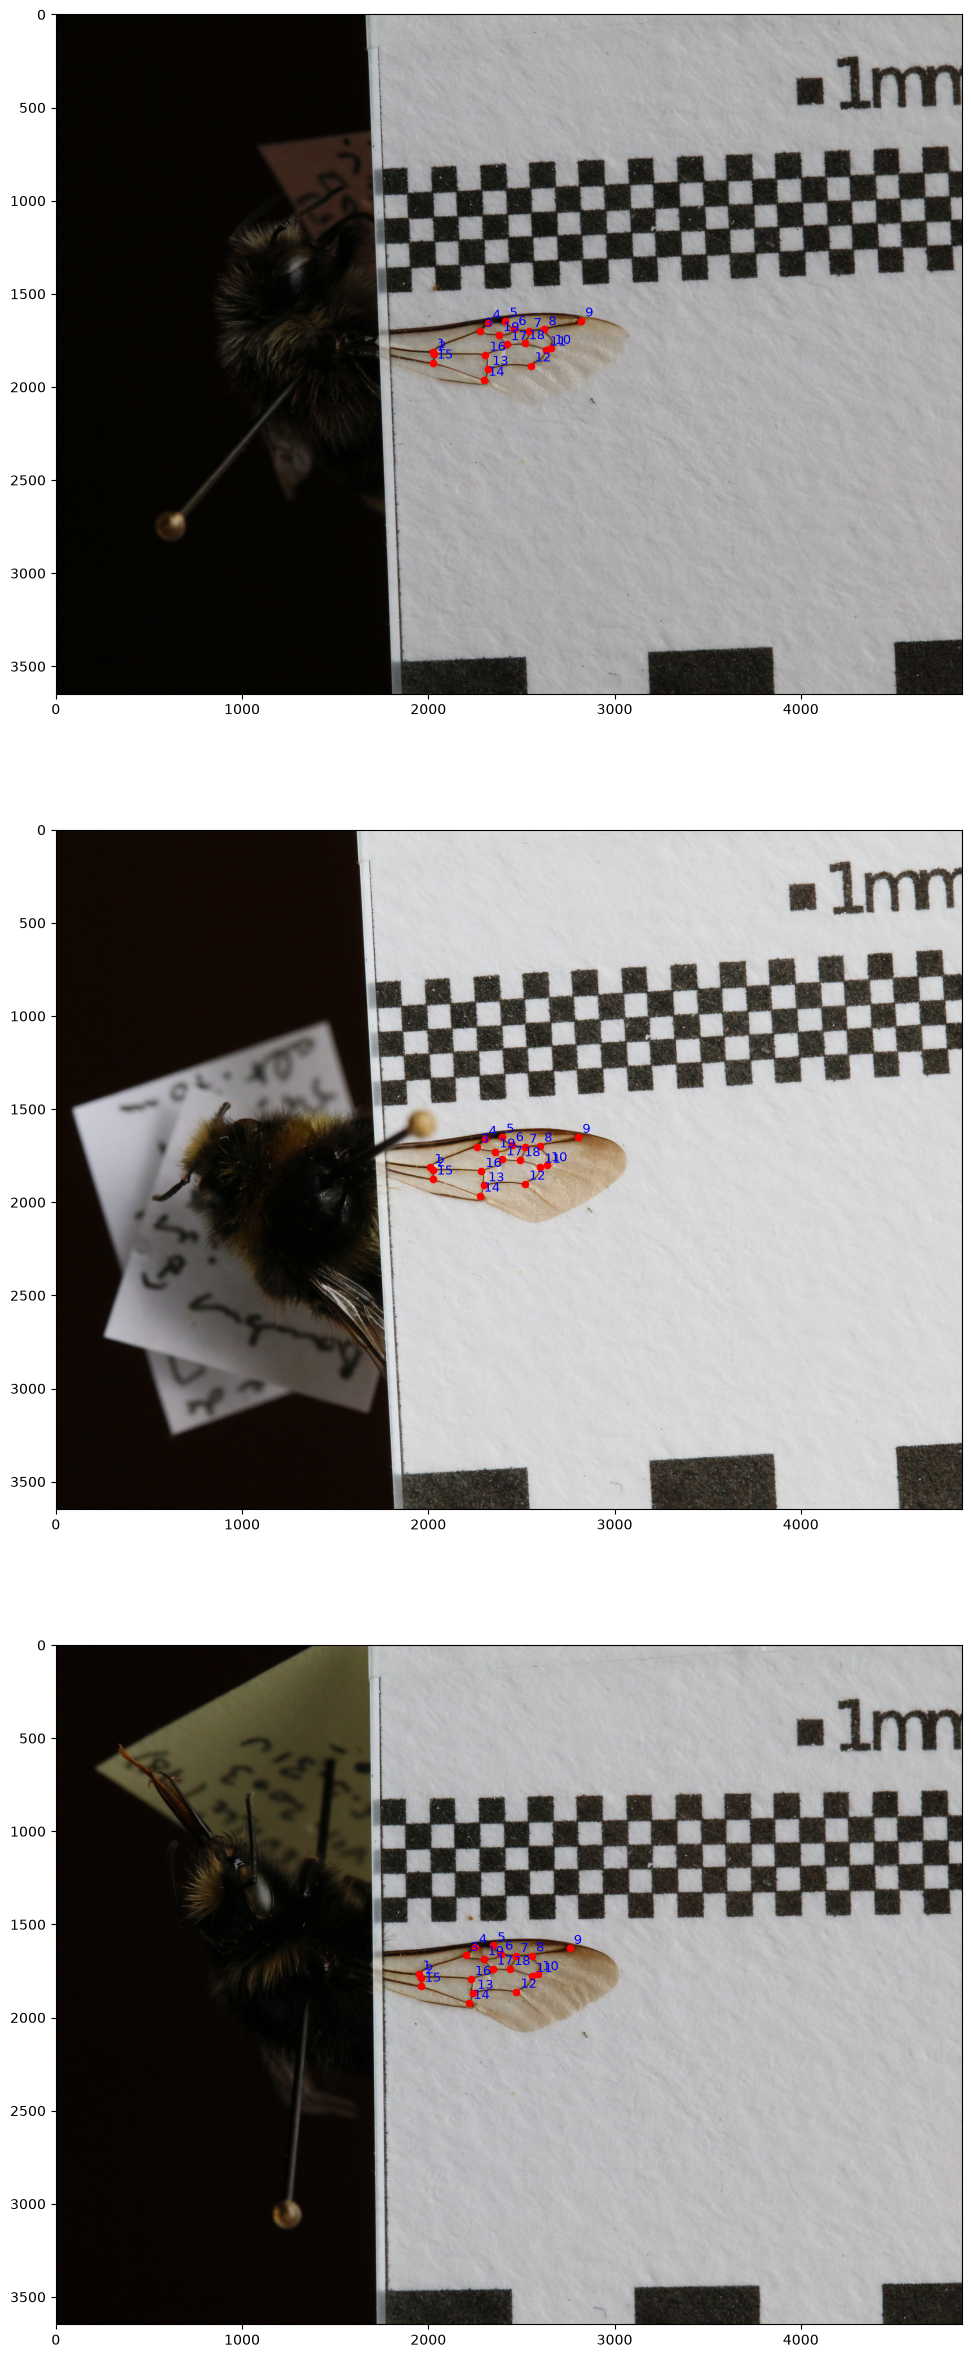

In [42]:
n = 3
fig, axes = plt.subplots(n, 1, figsize=(15, 10*n))

for i, spec in enumerate(specimens[:n]):
    image = cv2.imread(PROJECT_ROOT / spec.image_path)
    landmarks = spec.landmarks

    h, w = image.shape[:2]

    landmarks = spec.landmarks.copy()
    landmarks[:, 1] = h - landmarks[:, 1]

    axes[i].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[i].scatter(landmarks[:,0], landmarks[:,1], 20, 'r')

    for j, (x, y) in enumerate(landmarks):
        axes[i].annotate(str(j + 1), (x, y), color="blue", fontsize=9,
            xytext=(3, 3), textcoords="offset points")

plt.show()

## Modèle Gabriel

In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

model_name = "UNet_150_epoch_lr=0.001_seed=58_func=pow_param=30"
model_load = torch.load(MODEL_DIR / (model_name + '.pth'),
                        weights_only=False, map_location=device)
model_load.to(device)
model_load.eval()

wing_crops = pd.read_csv(LOGS_PATH)

In [4]:
def get_species(row):
    try:
        sp = row["image"].split('\\')[0].split('_')[1]
    except:
        sp = row["image"].split('\\')[0]
    return sp

def get_caste(row):
    return row["image"].split('\\')[1]

def get_device(row):
    return row["name"].split('_')[-1]

valids = wing_crops.loc[wing_crops.status == 'OK']
valids["espece"] = valids.apply(get_species, axis=1)
valids["caste"] = valids.apply(get_caste, axis=1)
valids["device"] = valids.apply(get_device, axis=1)

valids = valids.drop(valids[valids.espece == "Vrac"].index).reset_index()
valids[["name", "espece", "caste", "device"]].to_csv(METADATAS_OUT, index_label="id")

In [ ]:
crops = []
crops_t = []
out_crops = []
annotations = []

records = []

for i, row in tqdm(valids.iterrows(), total=valids.shape[0]):
    path = CROP_ROOT / row.image

    crop = cv2.imread(path)
    crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    crops.append(crop)

    crop_t = torch.Tensor(crop.transpose(2,0,1)/255).unsqueeze(0)
    crops_t.append(crop_t)

    crop_t = crop_t.to(device)
    output = model_load(crop_t).cpu().squeeze(0).detach().numpy().transpose(1,2,0)
    out_crops.append(output)

    output = output.squeeze(axis = 2)
    maximas = np.argwhere(local_maxima(output) == True)
    scores = np.array([output[pt[0],pt[1]] for pt in maximas])
    sorter = np.argsort(scores)
    maximas = maximas[sorter,:]
    maximas = maximas[-18:,:]
    annotations.append(maximas)

    records.append({
        "landmarks": maximas,
        "image_path": path,
        "specimen_id": i,
    })

  0%|          | 0/2732 [00:00<?, ?it/s]

In [7]:
with open(LANDMARKS_OUT, "w", encoding="utf-8") as f:
    for rec in records:
        lm = rec["landmarks"]
        f.write(f"LM={len(lm)}\n")
        for y, x in lm:
            f.write(f"{x:.4f} {y:.4f}\n")
        f.write(f"IMAGE={rec['image_path']}\n")
        f.write(f"ID={rec['specimen_id']}\n")

In [43]:
n = valids.shape[0]
sample_indices = np.random.choice(n, size=min(10, n), replace=False)

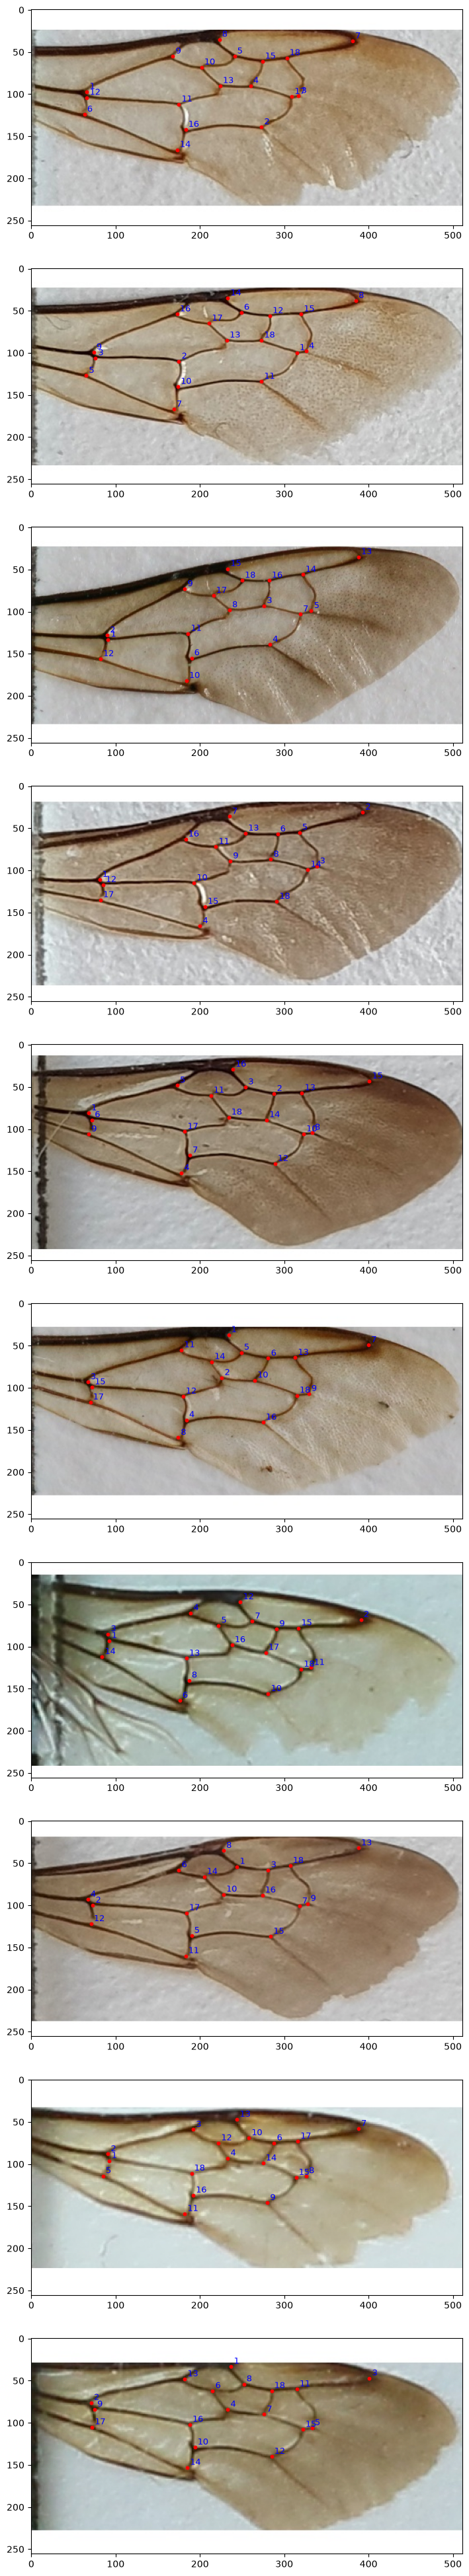

In [47]:
fig, axes = plt.subplots(10, 1, figsize=(10, 50))

for i, idx in enumerate(sample_indices):
    d = records[idx]
    
    image = cv2.imread(d["image_path"])
    landmarks = d["landmarks"]

    axes[i].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[i].scatter(landmarks[:,1], landmarks[:,0], 10, 'r')

    for j, (y, x) in enumerate(landmarks):
        axes[i].annotate(str(j + 1), (x, y), color="blue", fontsize=9,
            xytext=(3, 3), textcoords="offset points")

plt.show()